In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Upload the diabetic dataset
from google.colab import files
uploaded = files.upload()

# Load the CSV
df = pd.read_csv(next(iter(uploaded)))

# Display basic information
print("Dataset Shape:", df.shape)
display(df.head())

Saving diabetic_data.csv to diabetic_data (1).csv
Dataset Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


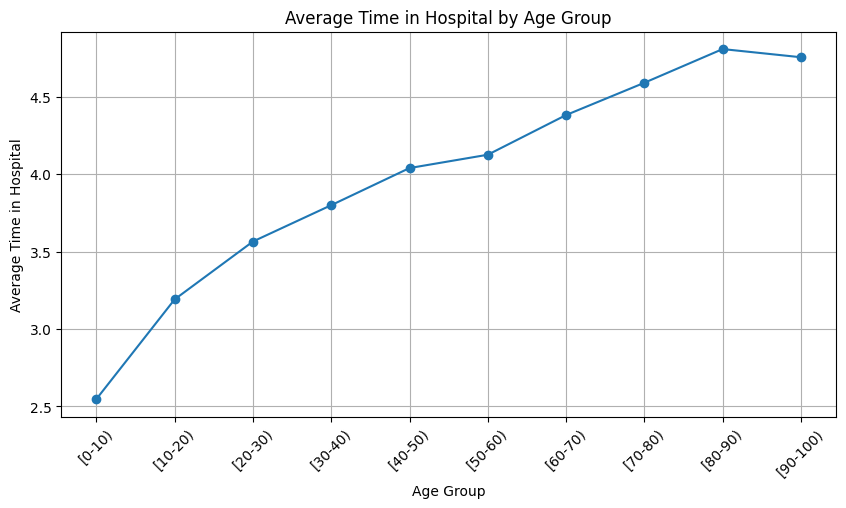

In [4]:
# Average time in hospital for each age group

avg_stay = df.groupby('age')['time_in_hospital'].mean()

plt.figure(figsize=(10, 5))
plt.plot(avg_stay.index, avg_stay.values, marker='o')

plt.title('Average Time in Hospital by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Time in Hospital')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

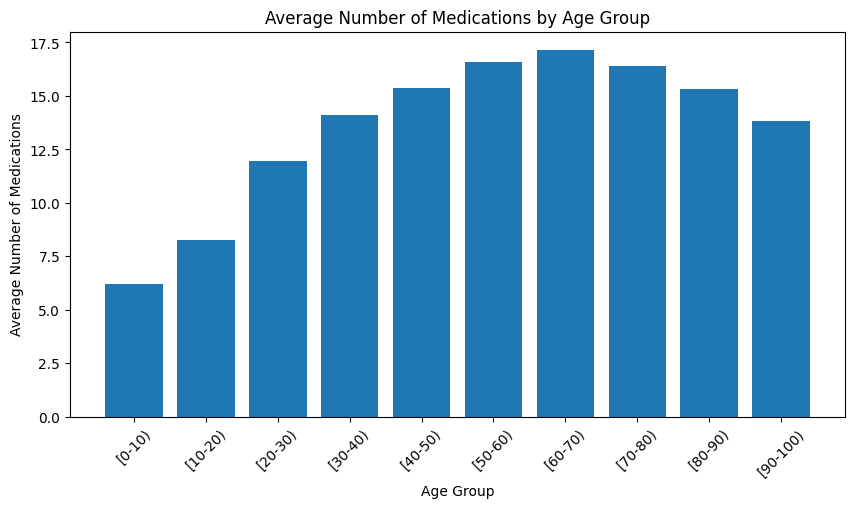

In [5]:
# Average number of medications for each age group

avg_meds = df.groupby('age')['num_medications'].mean()

plt.figure(figsize=(10, 5))
plt.bar(avg_meds.index, avg_meds.values)

plt.title('Average Number of Medications by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Number of Medications')
plt.xticks(rotation=45)

plt.show()

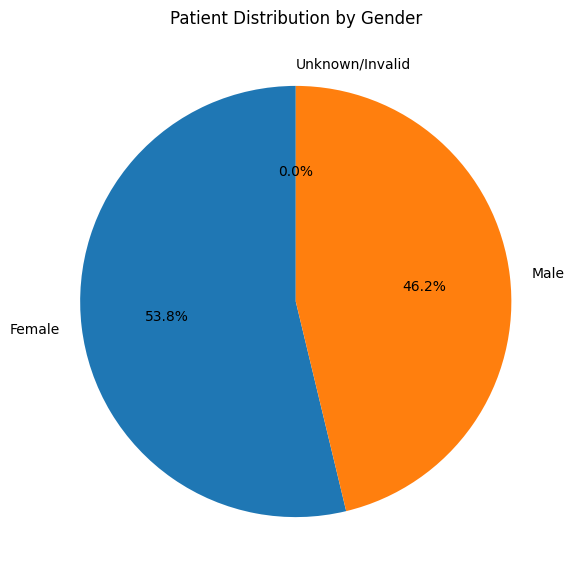

In [6]:
# Patient distribution by gender

gender_counts = df['gender'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Patient Distribution by Gender')
plt.show()

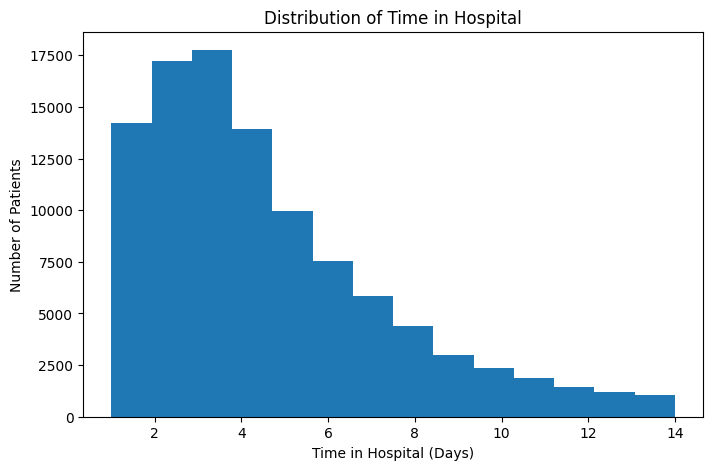

In [7]:
# Distribution of time spent in hospital

plt.figure(figsize=(8, 5))
plt.hist(df['time_in_hospital'], bins=14)

plt.title('Distribution of Time in Hospital')
plt.xlabel('Time in Hospital (Days)')
plt.ylabel('Number of Patients')

plt.show()

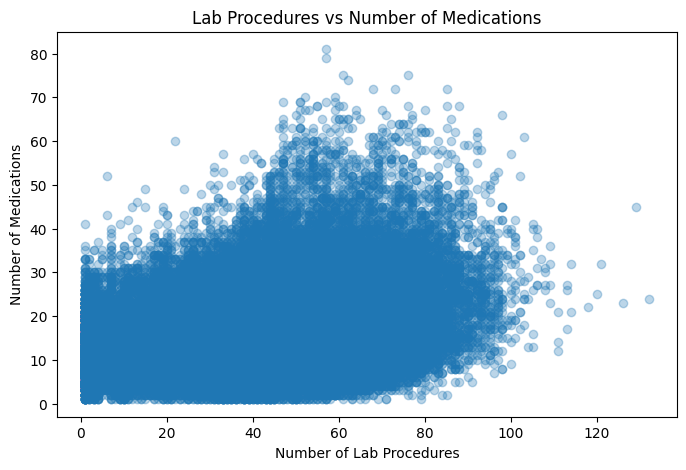

In [8]:
# Relationship between lab procedures and medications

plt.figure(figsize=(8, 5))
plt.scatter(
    df['num_lab_procedures'],
    df['num_medications'],
    alpha=0.3
)

plt.title('Lab Procedures vs Number of Medications')
plt.xlabel('Number of Lab Procedures')
plt.ylabel('Number of Medications')

plt.show()

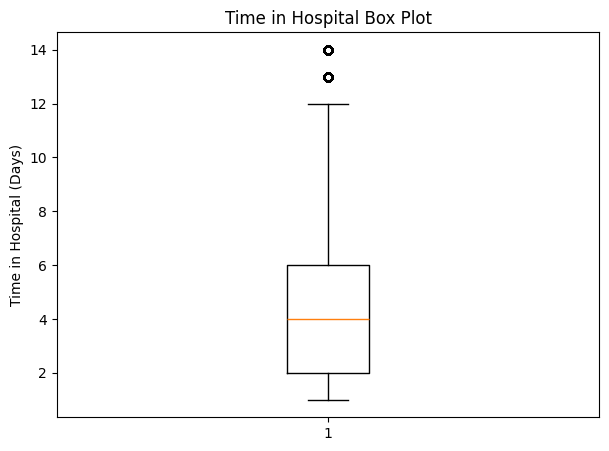

In [9]:
# Box plot of time spent in hospital

plt.figure(figsize=(7, 5))
plt.boxplot(df['time_in_hospital'].dropna())

plt.title('Time in Hospital Box Plot')
plt.ylabel('Time in Hospital (Days)')

plt.show()

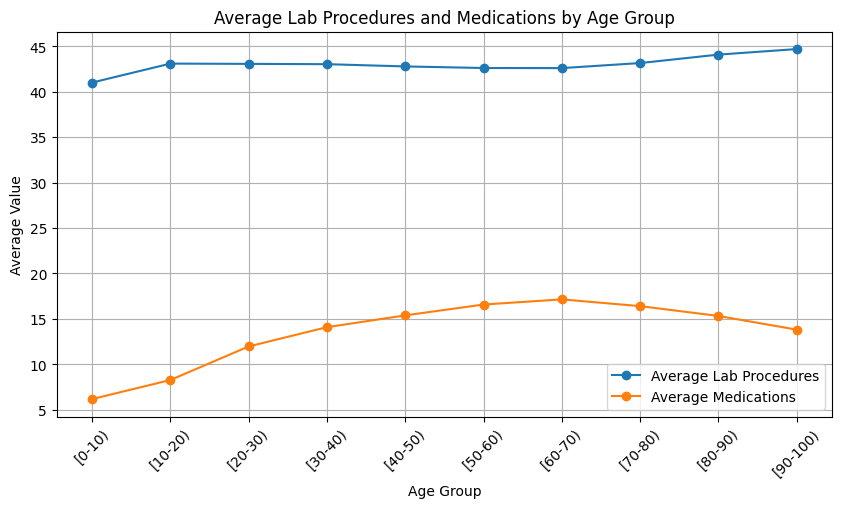

In [10]:
# Multiple line chart: Lab procedures vs medications by age group

age_analysis = df.groupby('age')[[
    'num_lab_procedures',
    'num_medications'
]].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    age_analysis.index,
    age_analysis['num_lab_procedures'],
    marker='o',
    label='Average Lab Procedures'
)

plt.plot(
    age_analysis.index,
    age_analysis['num_medications'],
    marker='o',
    label='Average Medications'
)

plt.title('Average Lab Procedures and Medications by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()